In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

In [58]:
# create image objects

circle_one = sitk.Image(512, 512, sitk.sitkFloat32)
circle_two = sitk.Image(512, 512, sitk.sitkFloat32)

In [59]:
# add metadata

dcm = (1,0,0,1)

circle_one.SetOrigin((0,0))
circle_one.SetSpacing((1,1))
circle_one.SetDirection(dcm)

circle_two.SetOrigin((0,0))
circle_two.SetSpacing((1,1))
circle_two.SetDirection(dcm)

In [60]:
# circle one should be 30 mm centered at 50, 50 mm
circle_one_center = circle_one.TransformPhysicalPointToIndex((50, 50))
print('50mm, 50mm -> \n', circle_one_center)

circle_one_radius = 30
for i in range(0, circle_one.GetSize()[0]):
    for j in range(0, circle_one.GetSize()[1]):

        pt = circle_one.TransformIndexToPhysicalPoint((i,j))

        # radius from center < circle radius, set to 1
        if np.sqrt((circle_one_center[0] - pt[0])**2 + (circle_one_center[1] - pt[1])**2) <= circle_one_radius:
            circle_one.SetPixel(i,j,1)


50mm, 50mm -> 
 (50, 50)


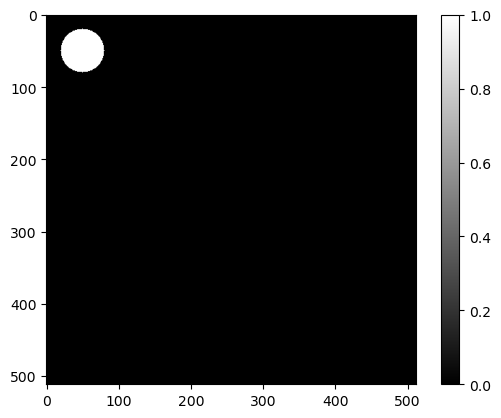

In [61]:
plt.imshow(sitk.GetArrayViewFromImage(circle_one), cmap='gray')
plt.colorbar()